In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_excel("D:\\P649_Bankruptcy_Prevention_Project\\bankruptcy-prevention (1).xlsx")
df.head()

,industrial_risk; management_risk; financial_flexibility; credibility; competitiveness; operating_risk; class
0,0.5;1;0;0;0;0.5;bankruptcy
1,0;1;0;0;0;1;bankruptcy
2,1;0;0;0;0;1;bankruptcy
3,0.5;0;0;0.5;0;1;bankruptcy
4,1;1;0;0;0;1;bankruptcy


In [3]:
df = df.iloc[:, 0].str.split(";", expand=True)
df.head()

,0,1,2,3,4,5,6
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


In [4]:
df.columns = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk",
    "class"
]
df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


In [5]:
for col in df.columns[:-1]:
    df[col] = pd.to_numeric(df[col])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [7]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [8]:
df.shape

(250, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [10]:
df['class'].value_counts()

class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64

In [11]:
df['class'].value_counts(normalize=True) * 100

class
non-bankruptcy    57.2
bankruptcy        42.8
Name: proportion, dtype: float64

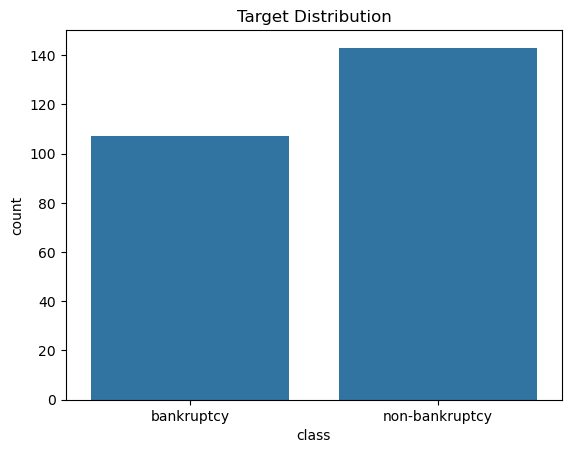

In [12]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.countplot(x='class', data=df)
plt.title("Target Distribution")
plt.show()

In [13]:
for col in df.columns[:-1]:
    print("\nColumn:", col)
    print(df[col].value_counts())


Column: industrial_risk
industrial_risk
1.0    89
0.5    81
0.0    80
Name: count, dtype: int64

Column: management_risk
management_risk
1.0    119
0.5     69
0.0     62
Name: count, dtype: int64

Column: financial_flexibility
financial_flexibility
0.0    119
0.5     74
1.0     57
Name: count, dtype: int64

Column: credibility
credibility
0.0    94
1.0    79
0.5    77
Name: count, dtype: int64

Column: competitiveness
competitiveness
0.0    103
1.0     91
0.5     56
Name: count, dtype: int64

Column: operating_risk
operating_risk
1.0    114
0.0     79
0.5     57
Name: count, dtype: int64


In [14]:
for col in df.columns[:-1]:
    print("\nColumn:", col)
    print(pd.crosstab(df[col], df['class']))


Column: industrial_risk
class            bankruptcy  non-bankruptcy
industrial_risk                            
0.0                      26              54
0.5                      28              53
1.0                      53              36

Column: management_risk
class            bankruptcy  non-bankruptcy
management_risk                            
0.0                      11              51
0.5                      23              46
1.0                      73              46

Column: financial_flexibility
class                  bankruptcy  non-bankruptcy
financial_flexibility                            
0.0                           102              17
0.5                             4              70
1.0                             1              56

Column: credibility
class        bankruptcy  non-bankruptcy
credibility                            
0.0                  87               7
0.5                  17              60
1.0                   3              76

Column:

In [15]:
for col in df.columns[:-1]:
    print("\nColumn:", col)
    print(pd.crosstab(df[col], df['class'], normalize='index') * 100)


Column: industrial_risk
class            bankruptcy  non-bankruptcy
industrial_risk                            
0.0               32.500000       67.500000
0.5               34.567901       65.432099
1.0               59.550562       40.449438

Column: management_risk
class            bankruptcy  non-bankruptcy
management_risk                            
0.0               17.741935       82.258065
0.5               33.333333       66.666667
1.0               61.344538       38.655462

Column: financial_flexibility
class                  bankruptcy  non-bankruptcy
financial_flexibility                            
0.0                     85.714286       14.285714
0.5                      5.405405       94.594595
1.0                      1.754386       98.245614

Column: credibility
class        bankruptcy  non-bankruptcy
credibility                            
0.0           92.553191        7.446809
0.5           22.077922       77.922078
1.0            3.797468       96.202532

Column:

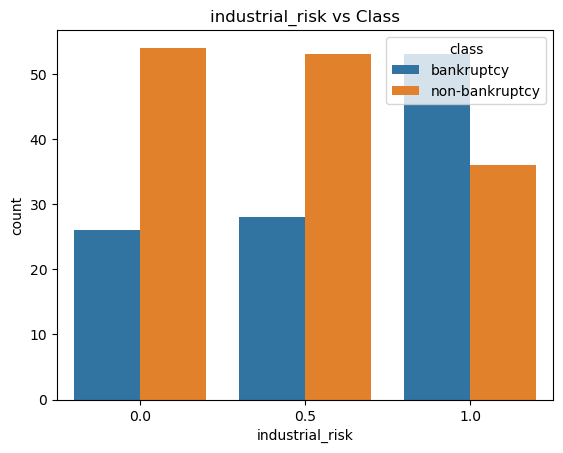

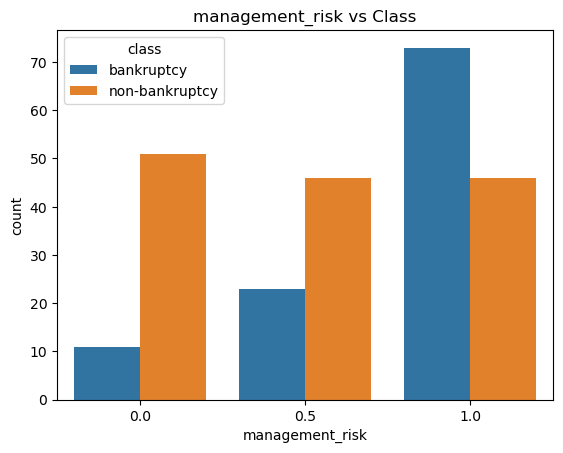

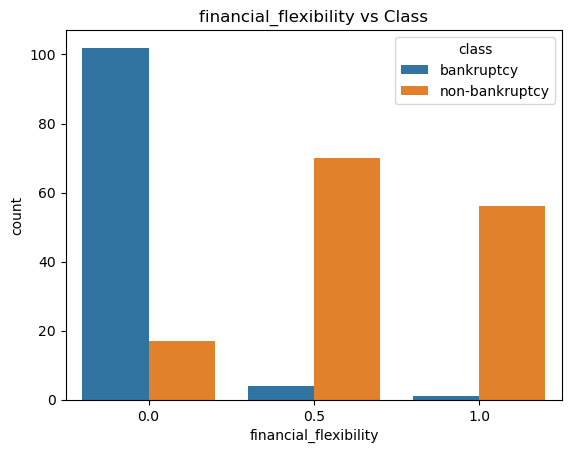

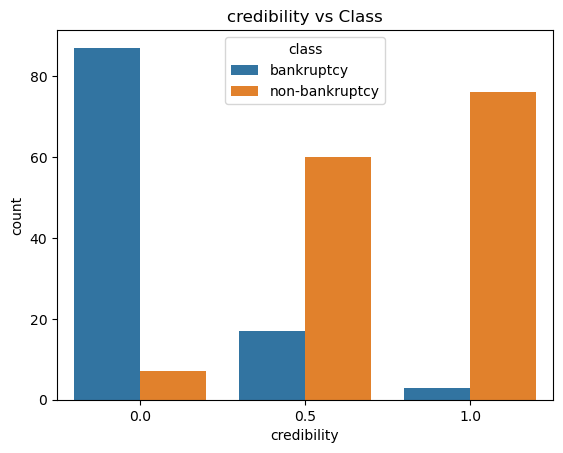

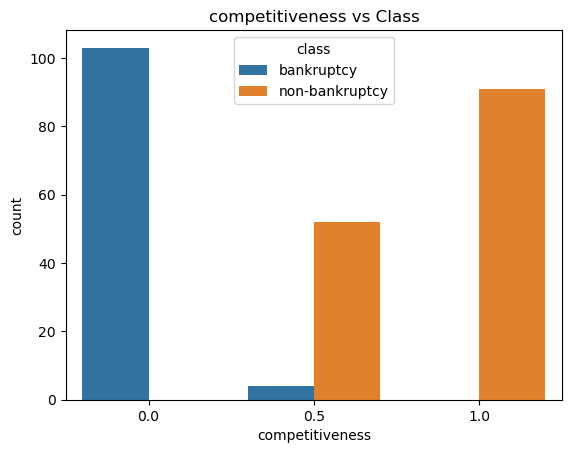

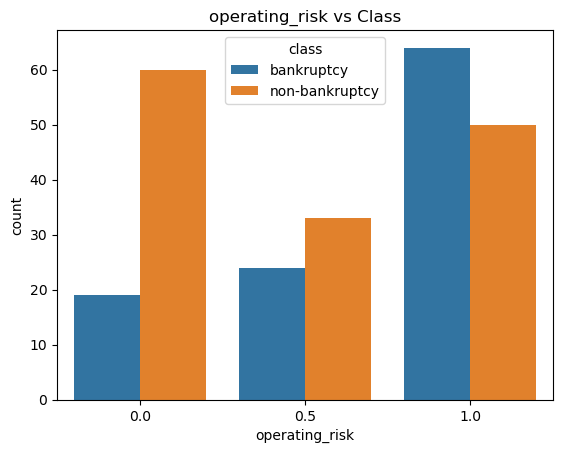

In [16]:
for col in df.columns[:-1]:
    plt.figure()
    sns.countplot(x=col, hue='class', data=df)
    plt.title(f"{col} vs Class")
    plt.show()

In [17]:
df.groupby('class').mean()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
class,,,,,,
bankruptcy,0.626168,0.789720,0.028037,0.107477,0.018692,0.710280
non-bankruptcy,0.437063,0.482517,0.636364,0.741259,0.818182,0.465035


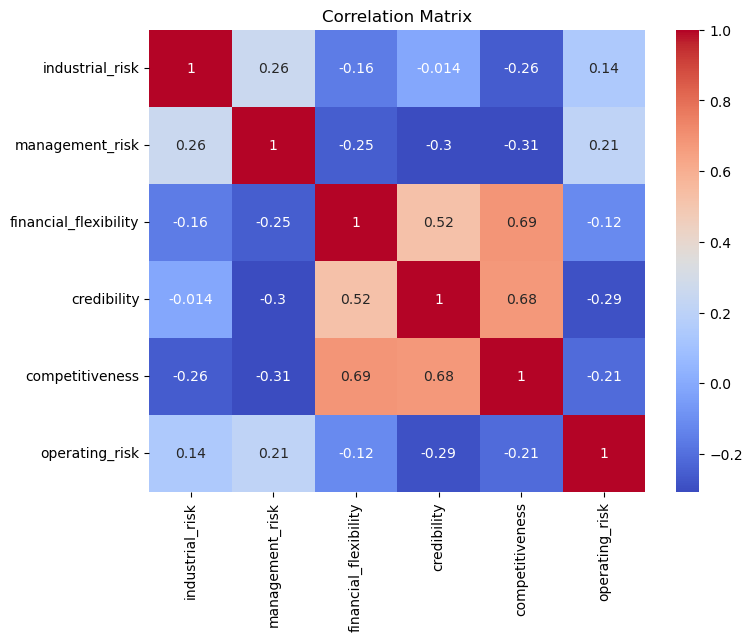

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [19]:
df.dtypes

industrial_risk          float64
management_risk          float64
financial_flexibility    float64
credibility              float64
competitiveness          float64
operating_risk           float64
class                     object
dtype: object

In [20]:
df.shape

(250, 7)

In [21]:
df.columns

Index(['industrial_risk', 'management_risk', 'financial_flexibility',
       'credibility', 'competitiveness', 'operating_risk', 'class'],
      dtype='object')

In [22]:
df.columns = df.columns.str.strip()

In [23]:
df.dtypes

industrial_risk          float64
management_risk          float64
financial_flexibility    float64
credibility              float64
competitiveness          float64
operating_risk           float64
class                     object
dtype: object

In [24]:
for col in df.columns[:-1]:
    print(col, df[col].unique())

industrial_risk [0.5 0.  1. ]
management_risk [1.  0.  0.5]
financial_flexibility [0.  0.5 1. ]
credibility [0.  0.5 1. ]
competitiveness [0.  0.5 1. ]
operating_risk [0.5 1.  0. ]


In [25]:
df.isnull().sum()

industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

In [26]:
df.duplicated().sum()

147

In [27]:
df.duplicated().value_counts()

True     147
False    103
Name: count, dtype: int64

In [28]:
df.shape

(250, 7)

In [29]:
df.value_counts().head(10)

industrial_risk  management_risk  financial_flexibility  credibility  competitiveness  operating_risk  class         
0.0              1.0              0.0                    0.0          0.0              1.0             bankruptcy        11
1.0              1.0              0.0                    0.0          0.0              1.0             bankruptcy        10
                                                                                       0.5             bankruptcy         9
0.5              1.0              0.0                    0.0          0.0              1.0             bankruptcy         8
                 0.5              0.0                    0.0          0.0              1.0             bankruptcy         7
0.0              0.5              0.0                    0.0          0.0              1.0             bankruptcy         5
0.5              1.0              0.0                    0.0          0.0              0.5             bankruptcy         5
1.0           

In [30]:
#checking Target cleanliness
df['class'].unique()


array(['bankruptcy', 'non-bankruptcy'], dtype=object)

In [31]:
#after encoding Target final ML check
df['class'] = df['class'].map({
    'bankruptcy': 1,
    'non-bankruptcy': 0
})

In [32]:
df.dtypes

industrial_risk          float64
management_risk          float64
financial_flexibility    float64
credibility              float64
competitiveness          float64
operating_risk           float64
class                      int64
dtype: object

In [33]:
#checking class balance after encoding again
df['class'].value_counts()

class
0    143
1    107
Name: count, dtype: int64

### =======================================================================

### Model Building

In [34]:
#defining standard ML structure
X = df.drop("class", axis=1)
y = df["class"]

In [35]:
#doing train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 
We are building 5 models. The Tree models ignore scaling but 

KNN uses distance,

SVM depends on margins,

Logistic regression benefits from scaling

In [37]:
#Model: Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [38]:
#Evaluation Function
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))



In [39]:
#evaluating logistic regression
evaluate("Logistic Regression", y_test, y_pred_log)


Logistic Regression
Accuracy 1.0
Confusion Matrix:
 [[29  0]
 [ 0 21]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [40]:
#Accuracy on the training data
log_model.score(X_train_scaled, y_train)

0.995

**The model correctly classified 99.5% of companies**

**so out of 200 training samples maybe 1 was misclassified**

In [41]:
log_model.coef_  #feature weights

array([[ 0.36707318,  0.51464659, -1.31895104, -1.42763097, -2.76101864,
         0.00668702]])

**Logistic regression coefficients indicate that competitiveness has the strongest protective effect against bankruptcy, followed by credibility and financial flexibility. Risk-related variables have smaller positive contributions to bankruptcy probability.**

In [42]:
#Model: KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

In [43]:
#evaluating KNN
evaluate("KNN", y_test, y_pred_knn)


KNN
Accuracy 0.98
Confusion Matrix:
 [[28  1]
 [ 0 21]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.95      1.00      0.98        21

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



**KNN achieved 98% accuracy with 100% recall for bankrupt firms. The single misclassification was a false positive, meaning a safe firm was predicted as bankrupt. From a risk-management perspective, this is less critical than missing bankrupt firms.**

In [44]:
#Model: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [45]:
#evaluating Decision tree
evaluate("Decision Tree", y_test, y_pred_dt)


Decision Tree
Accuracy 0.98
Confusion Matrix:
 [[28  1]
 [ 0 21]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.95      1.00      0.98        21

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [46]:
#checking  training accuracy for Decision Tree
dt_model.score(X_train, y_train)

1.0

In [47]:
#model: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [48]:
#evaluating RF
evaluate("Random Forest", y_test, y_pred_rf)


Random Forest
Accuracy 1.0
Confusion Matrix:
 [[29  0]
 [ 0 21]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [49]:
rf_model.score(X_train, y_train) #training accuracy

1.0

**Random Forest achieved perfect classification on the test set. The consistently high performance across models suggests that the dataset exhibits strong separability between bankrupt and non-bankrupt firms.**

In [50]:
#interpreting Random Forest
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

competitiveness          0.485679
financial_flexibility    0.221955
credibility              0.215781
management_risk          0.036441
industrial_risk          0.026195
operating_risk           0.013949
dtype: float64

**Random Forest feature importance analysis reveals that competitiveness accounts for nearly half of the model’s predictive power. Together with financial flexibility and credibility, these strength-related variables explain over 90% of bankruptcy classification decisions, indicating that internal company robustness is more critical than external risk factors.**

In [51]:
#Model: SVM 
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

In [52]:
#evaluating SVM
evaluate("SVM", y_test, y_pred_svm)


SVM
Accuracy 1.0
Confusion Matrix:
 [[29  0]
 [ 0 21]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [53]:
#creating Comparison table
results = pd.DataFrame({
    "Model": ["Logistic", "KNN", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic,1.00
3,Random Forest,1.00
4,SVM,1.00
1,KNN,0.98
2,Decision Tree,0.98


**Logistic Regression was selected because it achieved perfect test performance while maintaining full interpretability. The coefficient magnitudes aligned with EDA insights, particularly the dominant influence of competitiveness and financial flexibility. Since performance was equivalent to more complex models like Random Forest, the simpler and more transparent model was preferred for deployment.**

In [54]:
#feature sensitivity analysis
X_reduced = df.drop(["class", "competitiveness"], axis=1)
y = df["class"]

from sklearn.model_selection import train_test_split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_r_scaled = scaler.fit_transform(X_train_r)
X_test_r_scaled = scaler.transform(X_test_r)

from sklearn.linear_model import LogisticRegression
log_r = LogisticRegression()
log_r.fit(X_train_r_scaled, y_train_r)

log_r.score(X_test_r_scaled, y_test_r)         #feature removal experiment

1.0

**I performed a feature removal experiment by removing the most important variable, competitiveness, and retrained the logistic regression model to see if performance changed. The accuracy remained 100%, indicating that other features also strongly separate the classes.**

In [55]:
#cross-validation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

cv_scores = cross_val_score(pipeline, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Cross-validation scores: [1.   1.   1.   0.98 1.  ]
Mean CV accuracy: 0.9960000000000001


In [56]:
#checking overfitting

print("Logistic Train:", log_model.score(X_train_scaled, y_train))
print("Logistic Test:", log_model.score(X_test_scaled, y_test))

print("Decision Tree Train:", dt_model.score(X_train, y_train))
print("Decision Tree Test:", dt_model.score(X_test, y_test))

print("Random Forest Train:", rf_model.score(X_train, y_train))
print("Random Forest Test:", rf_model.score(X_test, y_test))

print("SVM Train:", svm_model.score(X_train_scaled, y_train))
print("SVM Test:", svm_model.score(X_test_scaled, y_test))

print("KNN Train:", knn_model.score(X_train_scaled, y_train))
print("KNN Test:", knn_model.score(X_test_scaled, y_test))

Logistic Train: 0.995
Logistic Test: 1.0
Decision Tree Train: 1.0
Decision Tree Test: 0.98
Random Forest Train: 1.0
Random Forest Test: 1.0
SVM Train: 1.0
SVM Test: 1.0
KNN Train: 0.995
KNN Test: 0.98


***we have choosen Logistic Regression.***

**Because:**

1.Acheived 100% test accuracy

2. High recall for bankruptcy

3. Stable cross-validation performance

4. Coefficients align with EDA

5. Transparent and interpretable

6. Simple for deployment

In [57]:
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

final_model.fit(X, y)

import joblib
joblib.dump(final_model, "bankruptcy_model.pkl")

['bankruptcy_model.pkl']

### ============================================================================

In [58]:
import joblib

loaded_model = joblib.load("bankruptcy_model.pkl")
print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


### Model Evaluation

In [59]:
#Predicttion probabilities
y_prob = final_model.predict_proba(X_test)[:,1]

In [60]:
print(y_prob[:10])

[0.99510709 0.01210171 0.05652753 0.00100436 0.00688288 0.97510185
 0.98214871 0.00546904 0.99228867 0.22859767]


In [61]:
y_prob

array([9.95107085e-01, 1.21017089e-02, 5.65275304e-02, 1.00435840e-03,
       6.88288288e-03, 9.75101855e-01, 9.82148715e-01, 5.46903731e-03,
       9.92288670e-01, 2.28597673e-01, 2.80473030e-04, 3.30370703e-01,
       9.94205892e-01, 2.30448378e-04, 9.96326176e-01, 8.61643678e-03,
       2.04141735e-04, 4.82741780e-02, 1.39568295e-02, 1.59360731e-03,
       9.29794448e-01, 9.29794448e-01, 9.92091412e-01, 1.39568295e-02,
       4.16874804e-03, 9.92288670e-01, 2.30448378e-04, 4.83240061e-02,
       1.03930291e-04, 7.60617301e-02, 9.75101855e-01, 9.87240906e-01,
       8.01236562e-01, 9.95107085e-01, 9.95107085e-01, 9.96326176e-01,
       9.96898617e-01, 9.96898617e-01, 6.88288288e-03, 7.78702039e-02,
       9.92091412e-01, 9.79004137e-01, 9.29794448e-01, 6.91372839e-03,
       5.65275304e-02, 1.03930291e-04, 1.64268567e-02, 2.86761396e-04,
       4.12160917e-02, 2.86761396e-04])

In [62]:
#calculating AUC score
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 1.0


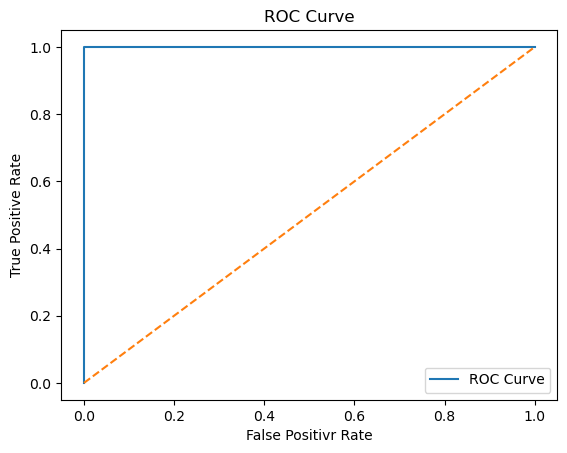

In [63]:
#Plot ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positivr Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**The ROC curve shows the relationship between the true positive rate and false positive rate across different classification thresholds. The curve reaching the top-left corner indicates that the model perfectly separates bankrupt and non-bankrupt companies, which is confirmed by the AUC score of 1.0.**

In [64]:
#for Threshold = 0.3
import numpy as np

y_pred_custom = (y_prob > 0.3).astype(int)

In [65]:
print(y_pred_custom)

[1 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 0 1 1 1 0 0 0 0 0 0 0]


In [66]:
#comparing predictions with this new threshold
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_custom)

array([[28,  1],
       [ 0, 21]], dtype=int64)

**To analyze the effect of decision thresholds, the classification threshold was lowered from 0.5 to 0.3. The confusion matrix shows that all bankrupt companies were still correctly detected, while only one non-bankrupt company was incorrectly classified as bankrupt. This demonstrates that lowering the threshold increases sensitivity to bankruptcy risk while slightly increasing false positives.**

In [67]:
y_prob = final_model.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob)

1.0

### ==========================================================================

### Model Deployment